In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("smart_electricity_bill_dataset.csv")
df

,house_type,month,avg_units_per_day,temperature,appliance_count,peak_hour_usage,subsidy_applied,power_cut_days,total_units,last_month_units,bill_amount,spike_flag
0,Industrial,6,4.246970,24.164636,15,8.456847,Yes,2,114.812124,71.137382,295.629975,1
1,Residential,12,3.762799,25.009659,26,6.127371,Yes,1,105.217407,119.443941,847.948474,0
2,Industrial,7,11.622032,36.118117,8,3.754533,Yes,4,294.132968,342.078785,2106.776358,0
3,Industrial,3,18.337601,25.593477,21,2.960192,No,2,581.509515,636.062048,3417.064601,0
4,Residential,7,7.255578,23.830426,12,3.944800,No,4,225.925680,255.455454,1153.680684,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2995,Industrial,6,10.714139,29.532483,8,7.907560,Yes,0,294.710952,277.447640,1833.420983,0
2996,Residential,4,11.289834,37.314020,35,1.641274,Yes,5,339.451416,355.281074,2423.623530,0
2997,Residential,2,14.738198,20.642192,7,9.299084,No,0,461.080095,474.203258,2841.355748,0
2998,Commercial,6,3.005302,32.877359,7,1.458766,Yes,1,104.046133,114.931357,518.706198,0


In [3]:
df.shape

(3000, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   house_type         3000 non-null   object 
 1   month              3000 non-null   int64  
 2   avg_units_per_day  3000 non-null   float64
 3   temperature        3000 non-null   float64
 4   appliance_count    3000 non-null   int64  
 5   peak_hour_usage    3000 non-null   float64
 6   subsidy_applied    3000 non-null   object 
 7   power_cut_days     3000 non-null   int64  
 8   total_units        3000 non-null   float64
 9   last_month_units   3000 non-null   float64
 10  bill_amount        3000 non-null   float64
 11  spike_flag         3000 non-null   int64  
dtypes: float64(6), int64(4), object(2)
memory usage: 281.4+ KB


In [5]:
df.isnull().sum()

house_type           0
month                0
avg_units_per_day    0
temperature          0
appliance_count      0
peak_hour_usage      0
subsidy_applied      0
power_cut_days       0
total_units          0
last_month_units     0
bill_amount          0
spike_flag           0
dtype: int64

In [6]:
df.describe()

,month,avg_units_per_day,temperature,appliance_count,peak_hour_usage,power_cut_days,total_units,last_month_units,bill_amount,spike_flag
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,6.530000,13.890342,29.777383,22.002667,5.480479,2.536333,417.080103,417.157108,2637.552971,0.043000
std,3.457902,6.350908,5.658864,10.012962,2.619607,1.692819,191.207311,193.435757,1179.636067,0.202891
min,1.000000,3.000676,20.001057,5.000000,1.002788,0.000000,58.938152,40.092002,6.260818,0.000000
25%,4.000000,8.358713,24.998893,13.000000,3.164459,1.000000,250.221482,252.021192,1649.560786,0.000000
50%,7.000000,13.736857,29.724296,22.000000,5.441946,3.000000,412.822260,413.757894,2633.980471,0.000000
75%,10.000000,19.395731,34.475822,31.000000,7.822268,4.000000,581.199620,582.895187,3604.244057,0.000000
max,12.000000,24.988135,39.990104,39.000000,9.999323,5.000000,781.360128,820.894638,5278.957018,1.000000


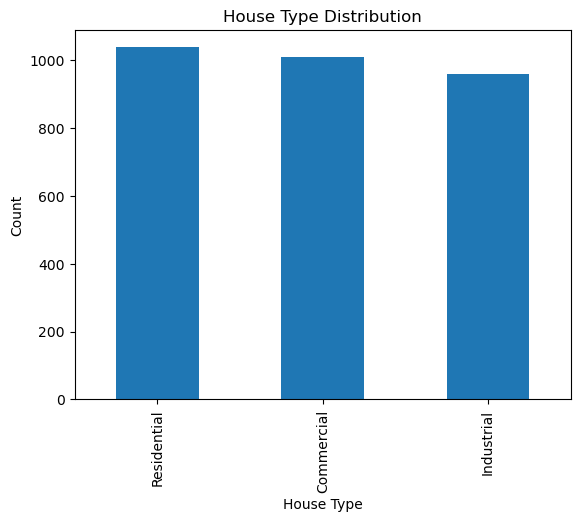

In [7]:
#Bar chart - House Type Distribution
df['house_type'].value_counts().plot(kind='bar')
plt.title("House Type Distribution")
plt.xlabel("House Type")
plt.ylabel("Count")
plt.show()

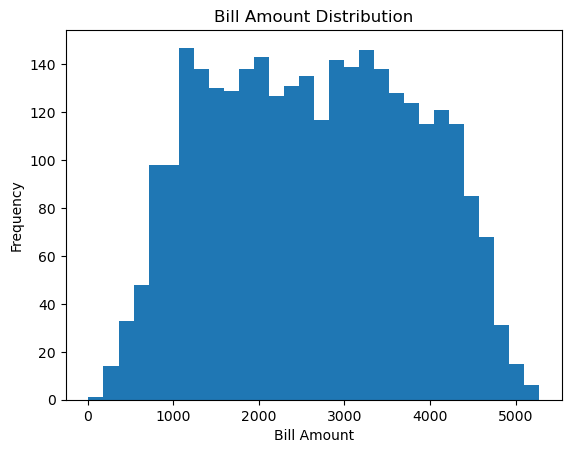

In [8]:
# histogram-Bill amount Distribution
plt.hist(df['bill_amount'], bins=30)
plt.title("Bill Amount Distribution")
plt.xlabel("Bill Amount")
plt.ylabel("Frequency")
plt.show()

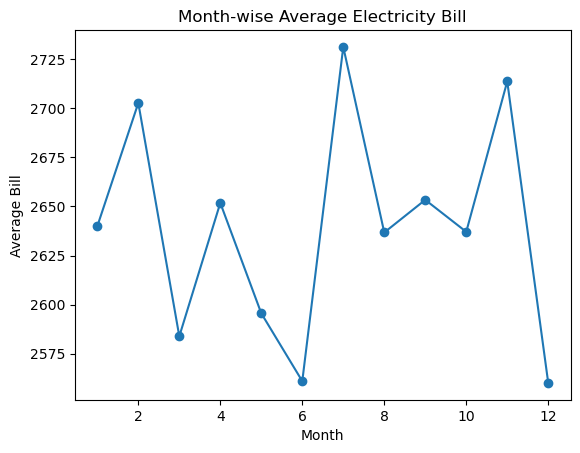

In [9]:
# Line chart- Month-wise Average bill
monthly_bill = df.groupby ('month')['bill_amount'].mean()

plt.plot(monthly_bill.index, monthly_bill.values, marker='o')
plt.title("Month-wise Average Electricity Bill")
plt.xlabel("Month")
plt.ylabel("Average Bill")
plt.show()

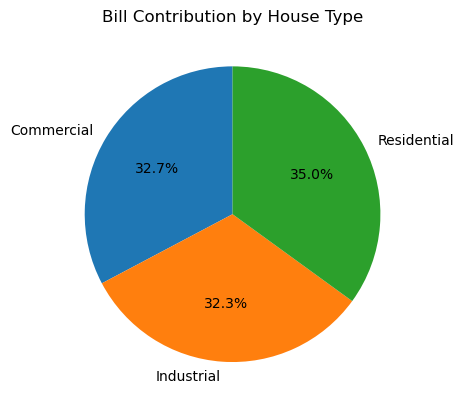

In [10]:
# Pie chart - Bill Contribution by House type
house_bill= df.groupby('house_type')['bill_amount'].sum()

plt.pie(house_bill.values,
        labels=house_bill.index,
        autopct='%1.1f%%',
        startangle=90)
plt.title("Bill Contribution by House Type")
plt.show()

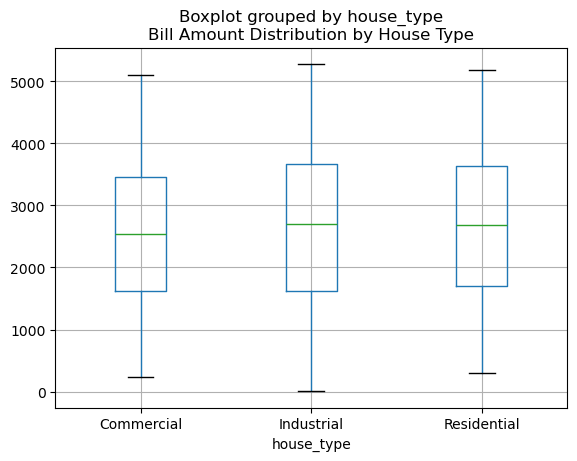

In [11]:
# Box plot - Bill Amount vs House Type
df.boxplot(column='bill_amount',by='house_type')
plt.title("Bill Amount Distribution by House Type")
plt.show()

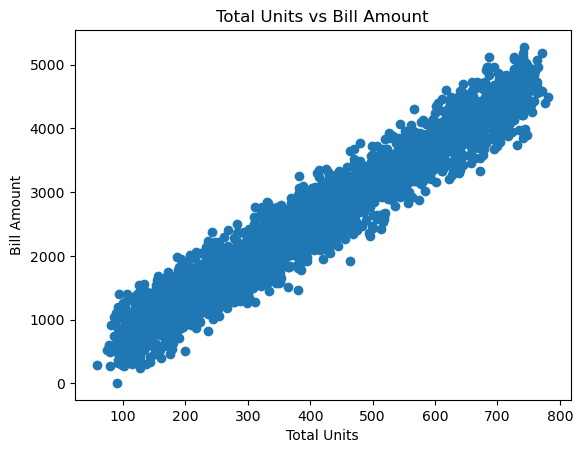

In [12]:
#Scatter plot - Total units vs Bill Amount
plt.scatter(df['total_units'],df['bill_amount'])
plt.title("Total Units vs Bill Amount")
plt.xlabel("Total Units")
plt.ylabel("Bill Amount")
plt.show()

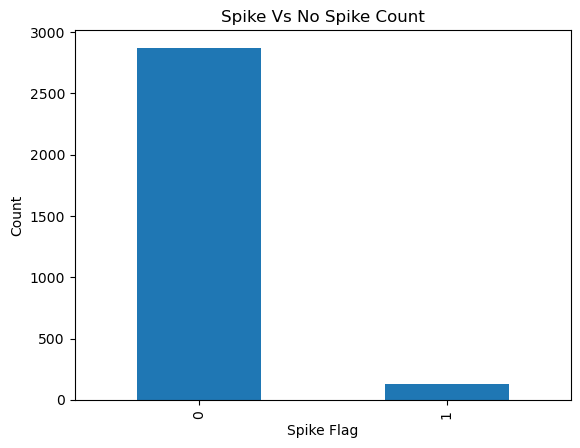

In [13]:
# Count plot - Spike vs No Spike
df['spike_flag'].value_counts().plot(kind='bar')
plt.title("Spike Vs No Spike Count")
plt.xlabel("Spike Flag")
plt.ylabel("Count")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

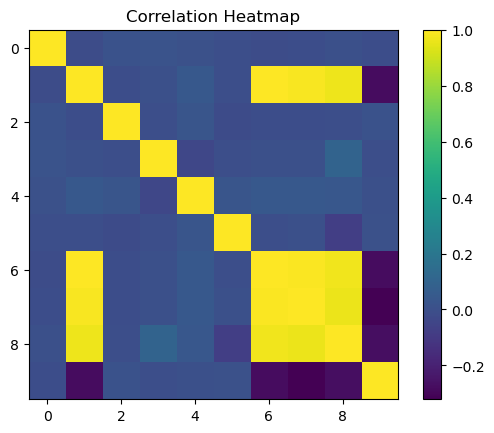

In [14]:
#correlation Heatmap
corr= df.select_dtypes(include=['int64','float64']).corr()

plt.imshow(corr)
plt.colorbar()
plt.title("Correlation Heatmap")
plt.show

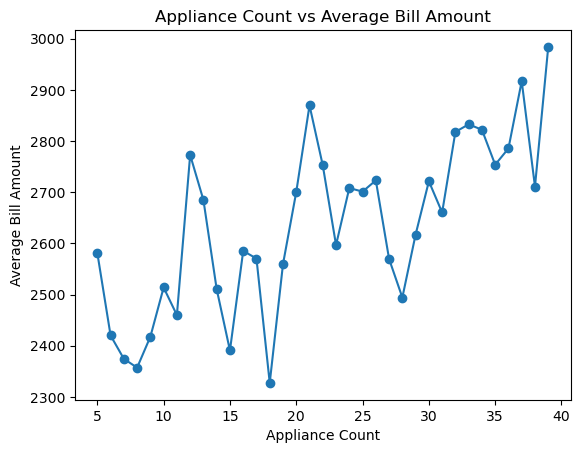

In [15]:
# line Chart - Appliance Count vs Average Bill Amount
appliance_bill= df.groupby('appliance_count')['bill_amount'].mean()

plt.figure()
plt.plot(appliance_bill.index,
         appliance_bill.values, marker='o')
plt.title("Appliance Count vs Average Bill Amount")
plt.xlabel("Appliance Count")
plt.ylabel("Average Bill Amount")
plt.show()

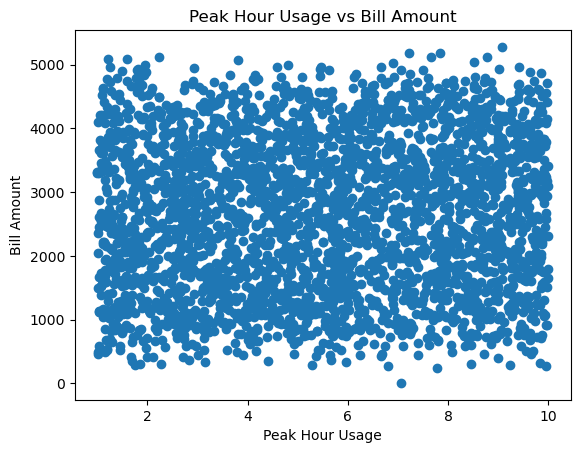

In [16]:
#Scatter plot - Peak hour usage vs Bill Amount 
plt.figure()
plt.scatter(df['peak_hour_usage'],df['bill_amount'])
plt.title("Peak Hour Usage vs Bill Amount")
plt.xlabel("Peak Hour Usage")
plt.ylabel("Bill Amount")
plt.show()

In [17]:
# Future Engineering & Encoding
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [18]:
le=LabelEncoder()
df['house_type']=le.fit_transform(df['house_type'])
df['subsidy_applied']=le.fit_transform(df['subsidy_applied'])

In [19]:
df

,house_type,month,avg_units_per_day,temperature,appliance_count,peak_hour_usage,subsidy_applied,power_cut_days,total_units,last_month_units,bill_amount,spike_flag
0,1,6,4.246970,24.164636,15,8.456847,1,2,114.812124,71.137382,295.629975,1
1,2,12,3.762799,25.009659,26,6.127371,1,1,105.217407,119.443941,847.948474,0
2,1,7,11.622032,36.118117,8,3.754533,1,4,294.132968,342.078785,2106.776358,0
3,1,3,18.337601,25.593477,21,2.960192,0,2,581.509515,636.062048,3417.064601,0
4,2,7,7.255578,23.830426,12,3.944800,0,4,225.925680,255.455454,1153.680684,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2995,1,6,10.714139,29.532483,8,7.907560,1,0,294.710952,277.447640,1833.420983,0
2996,2,4,11.289834,37.314020,35,1.641274,1,5,339.451416,355.281074,2423.623530,0
2997,2,2,14.738198,20.642192,7,9.299084,0,0,461.080095,474.203258,2841.355748,0
2998,0,6,3.005302,32.877359,7,1.458766,1,1,104.046133,114.931357,518.706198,0


In [20]:
# kurtosis & skewness
df.kurtosis()

house_type           -1.531703
month                -1.208270
avg_units_per_day    -1.198397
temperature          -1.145523
appliance_count      -1.178407
peak_hour_usage      -1.210985
subsidy_applied      -1.997228
power_cut_days       -1.245217
total_units          -1.186235
last_month_units     -1.146971
bill_amount          -1.051800
spike_flag           18.333287
dtype: float64

In [21]:
df.skew()

house_type          -0.017950
month               -0.013759
avg_units_per_day    0.041812
temperature          0.043365
appliance_count     -0.014609
peak_hour_usage      0.012014
subsidy_applied      0.064065
power_cut_days      -0.041521
total_units          0.039210
last_month_units     0.028864
bill_amount          0.030849
spike_flag           4.507889
dtype: float64

In [22]:
# Machine Learning Using Classification Algorithm

In [23]:
X = df.drop(['spike_flag','bill_amount'],axis=1)
y = df['spike_flag']

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [27]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# RandomForestClassifier 
from sklearn.ensemble import RandomForestClassifier

In [30]:
clf=RandomForestClassifier(n_estimators=200,max_depth=10,random_state=42)

In [33]:
clf.fit(X_train,y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
y_pred = clf.predict(X_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [38]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [40]:
print("Accuracy:", accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9716666666666667
[[569   4]
 [ 13  14]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       573
           1       0.78      0.52      0.62        27

    accuracy                           0.97       600
   macro avg       0.88      0.76      0.80       600
weighted avg       0.97      0.97      0.97       600



In [42]:
X = df.drop(['bill_amount', 'spike_flag'],axis=1)
y = df['bill_amount']

In [43]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [44]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [55]:
# RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor

In [56]:
reg = RandomForestRegressor(n_estimators=200,max_depth=12, random_state=42)

In [57]:
reg.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [58]:
y_pred = reg.predict(X_test)
y_pred

array([1424.35429025, 1559.62644282, 3154.37611607, 1208.16748612,
       2743.71164301, 2820.12926724, 1343.99638751,  889.23717915,
        633.63419057, 1218.59089183, 4318.90243479, 1841.44330753,
       4135.49853243, 1720.79607171, 4288.71787835, 2932.09923654,
       3889.07883499, 2342.9194567 ,  657.0058719 , 3669.56427487,
       3014.66048896, 2582.09364038, 3480.50520151, 2016.55964382,
       1491.7520147 , 1655.30260318, 1796.30218494,  972.53564354,
        831.6175785 , 2060.20771123, 1130.8489036 , 4628.70268263,
       4113.53954292,  972.06317965, 1073.00794375, 1315.0491939 ,
       1028.59291292, 1070.11915019, 3111.85612682, 2054.98821248,
       4628.95774559, 2953.41039525, 1862.76450599, 2780.35738698,
       1006.12793268, 1011.69609707, 3696.67048417, 4032.19890035,
       4552.68453748, 2593.95270446,  781.57631151, 1004.80360743,
       2679.50624303, 3520.97169433, 1208.82799153, 2182.90295566,
       4038.02342348, 1467.29921307, 1983.95793692, 1369.87105

In [59]:
from sklearn.metrics import r2_score, mean_squared_error

In [61]:
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.9456992826684625
RMSE: 276.182017971871
